# **Used Car Price Prediction**

### **Imports**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import joblib
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

### **Custom transformers**

In [3]:
class DataCleaner(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        if 'price' in X.columns:
            X['price'] = X['price'].str.replace("$", "").str.replace(",","").astype(float)
        
        X['milage'] = X['milage'].str.replace('mi.',"").str.replace(" mi.", "").str.replace(",", "").astype(float)
        
        X['accident'] = X['accident'].fillna('Unknown')
        X['had_accident'] = X['accident'].apply(lambda x: 1 if 'accident' in x.lower() else 0)
        X['accident_unknown'] = X['accident'].apply(lambda x: 1 if x == 'Unknown' else 0)
        X = X.drop(columns=['accident'])

        X['clean_title'] = X['clean_title'].fillna("No")
        X['clean_title'] = X['clean_title'].map({'Yes':1, 'No':0})

        X['fuel_type'] = X['fuel_type'].fillna('Unknown')

        return X

In [4]:
class FeatureEngineer(BaseEstimator, TransformerMixin):

    def __init__(self, current_year=None, luxury_brands=None):
        self.current_year = current_year if current_year else datetime.datetime.now().year
        self.luxury_brands = luxury_brands if luxury_brands else [
            'Lexus', 'INFINITI', 'Audi', 'Acura', 'BMW', 'Tesla', 'Land', 
            'Aston', 'Lincoln', 'Jaguar', 'Mercedes-Benz', 'Genesis', 'Bentley', 
            'Lucid', 'Porsche', 'Cadillac', 'Lamborghini', 
            'Maserati', 'Rivian', 'Alfa', 'Ferrari', 'Bugatti', 
            'Rolls-Royce', 'McLaren', 'Lotus', 'Karma', 'Maybach'
        ]
        self.fuel_columns_ = None
    
    def fit(self, X, y=None):
        X_temp = X.copy()
        fuel_dummies = pd.get_dummies(X_temp['fuel_type'], prefix='fuel', drop_first=True)
        self.fuel_columns_ = fuel_dummies.columns.tolist()
        return self

    def transform(self, X):
        X = X.copy()

        X['car_age'] = self.current_year - X['model_year']

        X['horsepower'] = X['engine'].str.extract(r"(\d+\.?\d*)HP", expand=False).astype(float)
        X['horsepower_missing'] = X['horsepower'].isna().astype(int)
        
        X['milage_per_year'] = X['milage'] / (X['car_age'] + 1)

        X['is_luxury'] = X['brand'].apply(lambda x: 1 if x in self.luxury_brands else 0)

        fuel_dummies = pd.get_dummies(X['fuel_type'], prefix='fuel', drop_first=True).astype(int)
        
        for col in self.fuel_columns_:
            if col not in fuel_dummies.columns:
                fuel_dummies[col] = 0
        
        fuel_dummies = fuel_dummies[self.fuel_columns_]
        
        X = pd.concat([X, fuel_dummies], axis=1)
        X = X.drop(columns=['fuel_type'])

        return X

In [5]:
class TargetEncoder(BaseEstimator, TransformerMixin):

    def __init__(self, column='brand', n_splits=5):
        self.column = column
        self.n_splits = n_splits
        self.encoding_map_ = None
        self.global_mean_ = None
    
    def fit(self, X, y=None):
        if y is None:
            raise ValueError("y is required for target encoding")
        
        X = X.copy()
        self.global_mean_ = y.mean()
        self.encoding_map_ = pd.DataFrame({self.column: X[self.column], 'target':y}).groupby(self.column)['target'].mean().to_dict()

        return self
    
    def transform(self, X):
        X = X.copy()

        X[f'{self.column}_encoded'] = X[self.column].map(self.encoding_map_).fillna(self.global_mean_)
        X = X.drop(columns=[self.column])
    
        return X

In [6]:
class OutlierRemover(BaseEstimator, TransformerMixin):

    def __init__(self, column='price', multiplier=1.5):
        self.column = column
        self.multiplier = multiplier
        self.lower_bound_ = None
        self.upper_bound_ = None
    
    def fit(self, X, y=None):
        Q1 = X[self.column].quantile(0.25)
        Q3 = X[self.column].quantile(0.75)
        IQR = Q3 - Q1

        self.lower_bound_ = Q1 - self.multiplier * IQR
        self.upper_bound_ = Q3 + self.multiplier * IQR

        return self
    
    def transform(self, X):
        X = X.copy()
        mask = (X[self.column] >= self.lower_bound_) & (X[self.column] <= self.upper_bound_)
        removed = len(X) - mask.sum()
        print(f"OutlierRemover: removed {removed:,} outliers ({removed/len(X)*100:.1f}%)")
        
        return X[mask]

In [7]:
class ColumnSelector(BaseEstimator, TransformerMixin):

    def __init__(self, columns):
        self.columns = columns
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X[self.columns].copy()

### **Main pipeline**

In [8]:
def create_preprocessing_pipeline():

    preprocessing_pipeline = Pipeline(steps=[
        ('cleaner', DataCleaner()),
        ('engineer', FeatureEngineer()),
        ('outlier_remover', OutlierRemover(column='price', multiplier=1.5))
    ])

    return preprocessing_pipeline


def create_model_pipeline(feature_columns):

    model_pipeline = Pipeline(steps=[
        ('column_selector', ColumnSelector(columns=feature_columns)),
        ('imputer', SimpleImputer(strategy='median')),
        ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
    ])

    return model_pipeline

### **Main execution**

In [9]:
def main():
    
    # load data
    df = pd.read_csv("used_cars.csv")
    print(f"Shape: {df.shape}")
    print(f"\n{df.head()}")


    # preprocessing pipeline
    preprocessing_pipeline = create_preprocessing_pipeline()
    df_processed = preprocessing_pipeline.fit_transform(df)

    print(f"Shape after preprocessing: {df_processed.shape}")
    print(f"Columns: {list(df_processed.columns)}")

    # target encoding
    X = df_processed.drop(columns=['price'])
    y = df_processed['price'].copy()

    y_log = np.log1p(y)

    X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

    print(f"Train samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    target_encoder = TargetEncoder(column='brand', n_splits=5)
    target_encoder.fit(X_train, np.expm1(y_train_log)) # fit on original data

    X_train_encoded = target_encoder.transform(X_train)
    X_test_encoded = target_encoder.transform(X_test)

    print("\nBrand encoding map (top 10):")
    sorted_brands = sorted(target_encoder.encoding_map_.items(), key=lambda x: x[1], reverse=True)[:10]
    for brand, mean_price in sorted_brands:
        print(f"{brand}: ${mean_price:,.0f}")
    
    # define features
    fuel_columns = [col for col in X_train_encoded.columns if col.startswith("fuel_")]
    feature_columns = [
        "milage", "car_age", "horsepower", "horsepower_missing",
        "had_accident", "accident_unknown", "clean_title", 
        "is_luxury", "brand_encoded", "milage_per_year"
    ] + fuel_columns
    print(f"\nFinal features ({len(feature_columns)}): {feature_columns}")

    # baseline model
    y_train_raw = np.expm1(y_train_log)
    y_test_raw = np.expm1(y_test_log)

    baseline = DummyRegressor(strategy='mean')
    baseline.fit(X_train_encoded[feature_columns], y_train_raw)
    y_pred_baseline = baseline.predict(X_test_encoded[feature_columns])

    baseline_mae = mean_absolute_error(y_test_raw, y_pred_baseline)
    baseline_rmse = root_mean_squared_error(y_test_raw, y_pred_baseline)
    baseline_r2 = r2_score(y_test_raw, y_pred_baseline)

    print(f"Baseline MAE: ${baseline_mae:,.2f}")
    print(f"Baseline RMSE: ${baseline_rmse:,.2f}")
    print(f"Baseline R²: {baseline_r2:.4f}")

    # model pipeline with hyperparameter tuning
    model_pipeline = create_model_pipeline(feature_columns)

    param_dist = {
    'regressor__n_estimators': [200, 300, 500],
    'regressor__max_depth': [10, 15, 20, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2', 0.3],
    'regressor__max_samples': [0.8, 0.9, None]
}

    random_search = RandomizedSearchCV(
        model_pipeline, param_distributions=param_dist, n_iter=50, cv=5, scoring='neg_mean_absolute_error',
        random_state=42, n_jobs=-1, verbose=1
    )

    random_search.fit(X_train_encoded, y_train_log)

    print("\nBest parameters:")
    for param, value in random_search.best_params_.items():
        print(f"{param}: {value}")
    
    best_cv_mae = -random_search.best_score_
    print(f"\n Best CV MAE (log scale): {best_cv_mae:.4f}")

    # model evaluation
    y_pred_log = random_search.predict(X_test_encoded)
    y_pred = np.expm1(y_pred_log)
    y_test = np.expm1(y_test_log)

    rf_mae = mean_absolute_error(y_test, y_pred)
    rf_rmse = root_mean_squared_error(y_test, y_pred)
    rf_r2 = r2_score(y_test, y_pred)

    improvement = (1 - rf_mae/baseline_mae) * 100
    
    print(f"\nRandom Forest results:")
    print(f"MAE: ${rf_mae:,.2f} ({improvement:+.1f}% vs baseline)")
    print(f"RMSE: ${rf_rmse:,.2f}")
    print(f"R²: {rf_r2:.4f}")

    results = pd.DataFrame({
        'Model': ['Baseline (Mean)', 'Random Forest (Pipeline)'],
        'MAE ($)': [baseline_mae, rf_mae],
        'RMSE ($)': [baseline_rmse, rf_rmse],
        'R²': [baseline_r2, rf_r2],
        'Improvement (%)': [0.0, improvement]
    })
    
    print(f"\n{results.to_string(index=False)}")
    
    if rf_r2 > 0.70:
        print(f"\nSuccess! Model explains {rf_r2*100:.1f}% of price variance")
        print(f"MAE improved by {improvement:.1f}% over baseline")
    elif rf_r2 > 0.50:
        print(f"\nModel explains {rf_r2*100:.1f}% of price variance")
    else:
        print(f"\nModel R^2 is {rf_r2:.3f} - needs improvement")
    
    # feature importance
    best_model = random_search.best_estimator_
    regressor = best_model.named_steps['regressor']
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': regressor.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(f"\n{feature_importance.to_string(index=False)}")
    print(f"\nTop 3 features account for {feature_importance.head(3)['Importance'].sum()*100:.1f}% of model decisions")

    plt.figure(figsize=(10, 8))
    top_n = min(15, len(feature_importance))
    plt.barh(feature_importance.head(top_n)['Feature'], feature_importance.head(top_n)['Importance'])
    plt.xlabel('Importance score')
    plt.ylabel('Feature')
    plt.title(f'Top {top_n} feature importance - Random Forest')
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    np.random.seed(123)
    n_examples = 5
    random_indices = np.random.choice(len(X_test), size=n_examples, replace=False)
    
    for i, idx in enumerate(random_indices, 1):
        actual = y_test.iloc[idx]
        predicted = y_pred[idx]
        error = predicted - actual
        error_pct = (error / actual) * 100
        
        print(f"\nCar {i}:")
        print(f"  Actual: ${actual:,.2f}")
        print(f"  Predicted: ${predicted:,.2f}")
        print(f"  Error: ${error:,.2f} ({error_pct:+.1f}%)")
    
    # save pipeline & artifacts
    try:
        joblib.dump(random_search.best_estimator_, 'car_price_pipeline.pkl')
        print("\nPipeline saved: car_price_pipeline.pkl")
        
        joblib.dump(preprocessing_pipeline, 'preprocessing_pipeline.pkl')
        print("Preprocessing pipeline saved: preprocessing_pipeline.pkl")
        
        joblib.dump(target_encoder, 'target_encoder.pkl')
        print("Target encoder saved: target_encoder.pkl")
        
        metadata = {
            'feature_columns': feature_columns,
            'fuel_columns': fuel_columns,
            'brand_encoding_map': target_encoder.encoding_map_,
            'global_mean': target_encoder.global_mean_,
            'test_metrics': {
                'mae': rf_mae,
                'rmse': rf_rmse,
                'r2': rf_r2
            },
            'best_params': random_search.best_params_,
            'training_date': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        joblib.dump(metadata, 'model_metadata.pkl')
        print("Metadata saved: model_metadata.pkl")
                
    except Exception as e:
        print(f"Error saving artifacts: {e}")
    

    loaded_preprocessing = joblib.load('preprocessing_pipeline.pkl')
    loaded_target_encoder = joblib.load('target_encoder.pkl')
    loaded_pipeline = joblib.load('car_price_pipeline.pkl')
    loaded_metadata = joblib.load('model_metadata.pkl')

    print(f"Model trained on: {loaded_metadata['training_date']}")
    print(f"Test R^2: {loaded_metadata['test_metrics']['r2']:.4f}")

    sample_raw = df.iloc[X_test.index[0]:X_test.index[0]+1].copy()

    print(f"\nSample car:")
    print(f"Brand: {sample_raw['brand'].values[0]}")
    print(f"Model: {sample_raw['model'].values[0]}")
    print(f"Year: {sample_raw['model_year'].values[0]}")

    sample_processed = loaded_preprocessing.transform(sample_raw)
    sample_processed = sample_processed.drop(columns=['price'])
    sample_encoded = loaded_target_encoder.transform(sample_processed)
    prediction_log = loaded_pipeline.predict(sample_encoded)
    prediction = np.expm1(prediction_log)[0]

    print(f"\nPredicted price: ${prediction:,.2f}")

### **Run**

Shape: (4009, 12)

      brand                            model  model_year      milage  \
0      Ford  Utility Police Interceptor Base        2013  51,000 mi.   
1   Hyundai                     Palisade SEL        2021  34,742 mi.   
2     Lexus                    RX 350 RX 350        2022  22,372 mi.   
3  INFINITI                 Q50 Hybrid Sport        2015  88,900 mi.   
4      Audi        Q3 45 S line Premium Plus        2021   9,835 mi.   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L V6 24V GDI DOHC   
2       Gasoline                                     3.5 Liter DOHC   
3         Hybrid  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...   
4       Gasoline                         2.0L I4 16V GDI DOHC Turbo   

        transmission                 ext_col int_col  \
0        6-Speed A/T                   Black   Black   
1  8-Spee

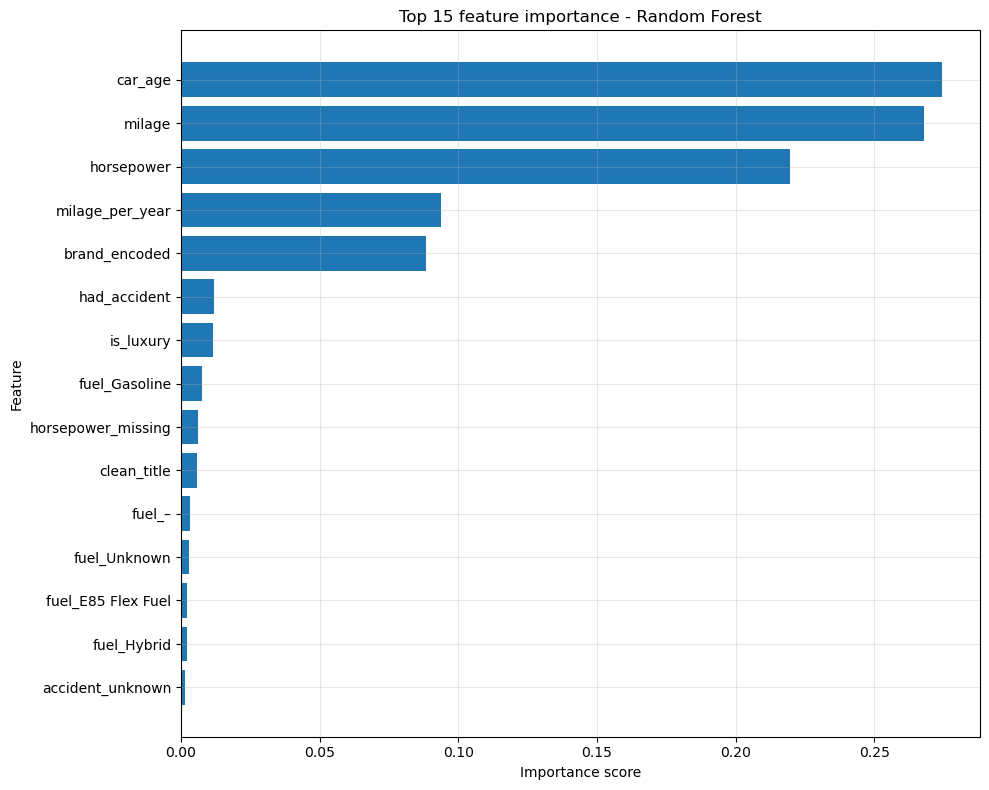


Car 1:
  Actual: $16,900.00
  Predicted: $21,138.48
  Error: $4,238.48 (+25.1%)

Car 2:
  Actual: $16,000.00
  Predicted: $15,322.40
  Error: $-677.60 (-4.2%)

Car 3:
  Actual: $25,900.00
  Predicted: $27,869.14
  Error: $1,969.14 (+7.6%)

Car 4:
  Actual: $27,000.00
  Predicted: $27,903.50
  Error: $903.50 (+3.3%)

Car 5:
  Actual: $61,998.00
  Predicted: $46,866.47
  Error: $-15,131.53 (-24.4%)

Pipeline saved: car_price_pipeline.pkl
Preprocessing pipeline saved: preprocessing_pipeline.pkl
Target encoder saved: target_encoder.pkl
Metadata saved: model_metadata.pkl
Model trained on: 2026-02-15 13:57:52
Test R^2: 0.7633

Sample car:
Brand: Buick
Model: Enclave Leather
Year: 2015
OutlierRemover: removed 0 outliers (0.0%)

Predicted price: $19,798.02


In [10]:
if __name__ == "__main__":
    main()